# 01 · Flight data and the magnetic anomaly map

**Magnetic navigation** locates an aircraft without GPS by matching the local strength of Earth's magnetic field to a pre-surveyed **anomaly map**. Iron-bearing rocks in the crust make the field stronger or weaker from place to place, and that fixed spatial pattern works like a terrain map you can navigate against.

This notebook loads one flight and the map it flew over, and checks the basic premise: *does the measured field actually follow the map along the route?*

> Data lives in `data/` — see the README or run `python tools/get_data.py` first.

In [12]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


In [13]:
%matplotlib inline
import numpy as np
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import viz

## Load the flight and pick one straight survey line
The SGL flights are magnetically-clean Cessna surveys. We take flight 1003, cut out one long straight line ("1003.02", ~63 min) and decimate 10 Hz → 2 Hz to stay fast. `lat`/`lon` are the true (GPS) positions, in radians.

In [14]:
nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
idx = segment_indices(nav, 50713.0, 54497.0)[::5]
lat = np.radians(nav.get('lat')[idx]); lon = np.radians(nav.get('lon')[idx])
print(f'samples: {idx.size}, dt={nav.dt:.3f}s')
print(f'map: {mag_map.grid.shape}, alt={mag_map.alt:.0f} m, values {mag_map.grid.min():.0f}..{mag_map.grid.max():.0f} nT')

samples: 7569, dt=0.100s
map: (4881, 6238), alt=395 m, values -1463..7447 nT


## The flight path over the anomaly map
In the plot below, **colour** is the map's magnetic field value in nanotesla (nT) and the **black line** is the aircraft's GPS track. Notice how the field changes along the route — that variation is exactly what makes position-fixing possible.

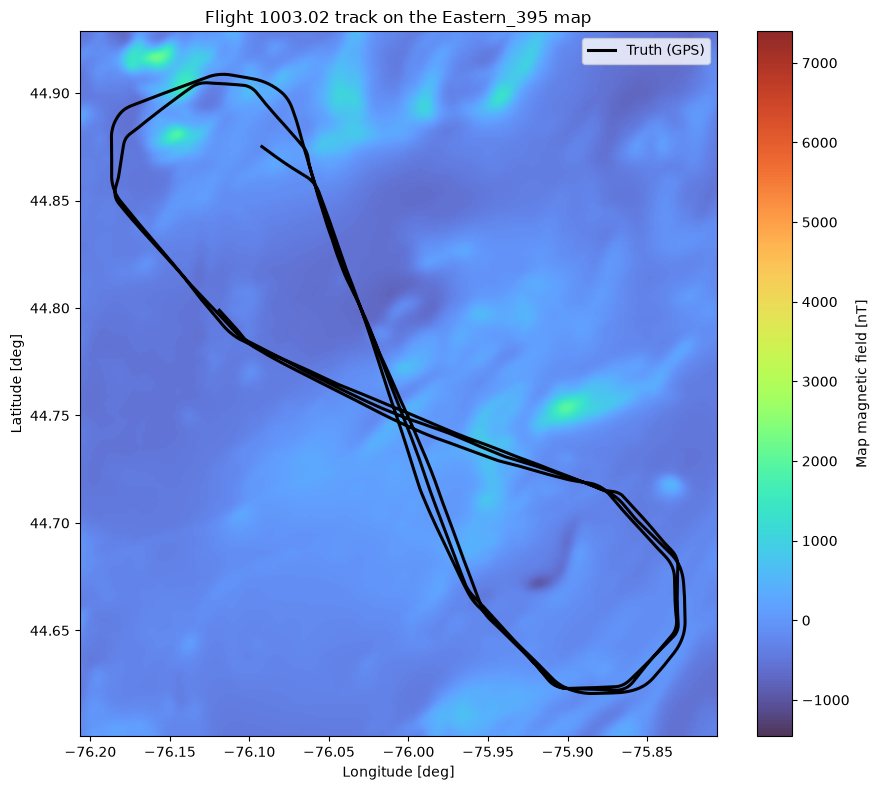

In [15]:
viz.plot_map_tracks(mag_map, lat, lon, {}, title='Flight 1003.02 track on the Eastern_395 map');

## Does the measurement follow the map?
The tail-boom ("stinger") magnetometer `mag_1_c` reads the total field. After removing a constant offset it should trace the map value sampled along the true path. The plot overlays the two signals against time — **black = measurement, orange = map**. They nearly coincide, and the printed correlation (~0.98) confirms the field is a reliable navigation signature.

measurement/map correlation: 0.988


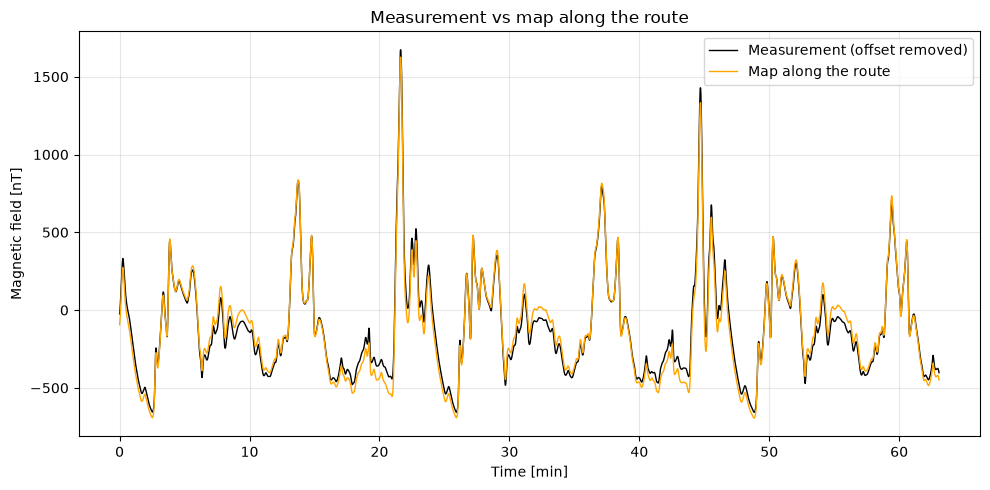

In [23]:
scalar = nav.get('mag_1_uc')[idx] - nav.get('diurnal')[idx]
map_along = mag_map.value(lat, lon)
scalar = scalar - np.median(scalar - map_along)
print(f'measurement/map correlation: {np.corrcoef(scalar, map_along)[0,1]:.3f}')
viz.plot_signal_vs_map(nav.get('tt')[idx], scalar, map_along);
